# ch17 · RLHF / 偏好模型概率机制

## Why this chapter
RLHF 是工业 LLM 对齐的核心流水线: 用 human preference 训 reward model, 再用 PPO/DPO 对 policy 微调. 这一章给你从头到尾的概率推导, 让你看懂论文 PPO clip 公式与 DPO 的 log-ratio 公式为什么是这样写.

## 学完后能解决
- 写 Bradley-Terry 与 Plackett-Luce 的 pairwise/列表 preference 模型
- 推 PPO 目标 `E_t[min(r_t A_t, clip(r_t, 1-ε, 1+ε)·A_t)]` 与原始 policy gradient 的差异
- 推 DPO 闭式目标: $\min_\theta -\log\sigma(\beta \log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \beta \log\frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)})$
- 用 toy 数据跑 mini-PPO 与 mini-DPO 看效果对比


## 2. 直觉: pairwise preference 怎么读
两个 response `y_w` (good) 与 `y_l` (bad); 人偏好 y_w 概率记为
$$P(y_w \succ y_l | x) = \sigma(r_\theta(x, y_w) - r_\theta(x, y_l))$$
这就是 Bradley-Terry 模型; reward `r_θ` 是从神经网络输出标量。


In [1]:
import numpy as np
import torch
import torch.nn.functional as F

torch.manual_seed(20240717)
# 4 个 response, 各自 reward
rewards_t = torch.tensor([0.8, 1.1, 0.3, 0.5], requires_grad=True)
# Pairwise preferences: [(y_w, y_l), ...]
pairs = [(1, 2), (0, 2), (1, 3), (0, 3)]

loss = 0.0
for w_idx, l_idx in pairs:
    diff = rewards_t[w_idx] - rewards_t[l_idx]
    log_likelihood = -F.logsigmoid(diff)
    loss = loss + log_likelihood
loss = loss / len(pairs)
loss.backward()
print(f"BT loss = {loss.item():.4f}")
print(f"rewards grad = {rewards_t.grad}")


BT loss = 0.4593
rewards grad = tensor([-0.2008, -0.1661,  0.1719,  0.1950])


## 3. 公式

### Bradley-Terry (pairwise)
$$P(y_w \succ y_l | x) = \sigma(r(x, y_w) - r(x, y_l))$$

### Plackett-Luce (top-k ordering)
$$P(y_1 \succ y_2 \succ ... \succ y_k | x) = \prod_{i=1}^{k} \frac{e^{r(x, y_i)}}{\sum_{j=i}^{k} e^{r(x, y_j)}}$$

### PPO clipped objective
$$L^{CLIP}(\theta) = \hat E_t \left[ \min(r_t(\theta) \hat A_t,\, \mathrm{clip}(r_t, 1-\epsilon, 1+\epsilon) \hat A_t)\right]$$
其中 $r_t(\theta) = \pi_\theta(a_t | s_t) / \pi_{\theta_{old}}(a_t | s_t)$ 是概率比, $\hat A_t$ 为 advantage.

### KL-regularized RL objective
$$\max_\pi \mathbb E_{y \sim \pi(\cdot|x)}[r(x,y)] - \beta\, D_{KL}(\pi(\cdot|x) \| \pi_{ref}(\cdot|x))$$

### DPO 闭式 (推导)
最优 policy 在上述 KL-正则问题下:
$$\pi^*(y|x) = \frac{1}{Z(x)} \pi_{ref}(y|x) \exp\left(\frac{r(x,y)}{\beta}\right)$$
反转求 reward:
$$r(x,y) = \beta \log \frac{\pi^*(y|x)}{\pi_{ref}(y|x)} + \beta \log Z(x)$$
代入 Bradley-Terry
$$P(y_w \succ y_l | x) = \sigma(r(x, y_w) - r(x, y_l))$$
$Z(x)$ 项对消; 得
$$L^{DPO} = -\log\sigma\left( \beta \log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \beta \log\frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}\right)$$


## 4. 推导: BT 对应的 reparameterized RL 问题


In [2]:
import sympy as sp
r_w, r_l, beta = sp.symbols("r_w r_l beta", real=True)
# BT = sigmoid(r_w - r_l); 在 KL-正则 RL 中
# π*(y|x) ∝ π_ref(y|x) exp(r/β)
# BT optimal prediction:
# P(y_w > y_l | π*) = σ(β log((π*(y_w|x)/π_ref(y_w|x)) - β log((π*(y_l|x)/π_ref(y_l|x))))
#   = σ(β (log_r_w - log_r_l))
# 这是 DPO 的核心 - reward differation 归化为 R/P(ratio) 的概率差
# 即可参数 π*(y|x) = π_ref(y|x) exp(r/β) / Z(x), Z(x) 是与 y 无关归一化系数
print("BT logit  ∝ β (log π*(y_w|x)/π_ref(y_w|x) - log π*(y_l | x) / π_ref(y_l | x))")
print("DPO loss  = -log σ( β log p_w/pref_w - β log p_l/pref_l )")


BT logit  ∝ β (log π*(y_w|x)/π_ref(y_w|x) - log π*(y_l | x) / π_ref(y_l | x))
DPO loss  = -log σ( β log p_w/pref_w - β log p_l/pref_l )


## 5. 数值 verify: DPO toy objective


In [3]:
import torch
import torch.nn.functional as F
torch.manual_seed(20240717)

# 给一个样本 (prompt + chosen + rejected)
vocab_size = 12; seq_len_c = 4; seq_len_l = 4

# reference 与 current 都用 logits
ref_logits_w = torch.randn(seq_len_c, vocab_size); ref_logits_l = torch.randn(seq_len_l, vocab_size)
cur_w_logits = torch.randn(seq_len_c, vocab_size, requires_grad=True); cur_l_logits = torch.randn(seq_len_l, vocab_size, requires_grad=True)
# chosen token ids; we 训练 current 推高 chosen prob 减 low chosen prob
w_ids = torch.tensor([0, 3, 5, 10]); l_ids = torch.tensor([2, 2, 7, 1])

log_prob_ref_w = F.log_softmax(ref_logits_w, dim=-1).gather(1, w_ids[:, None]).sum()
log_prob_ref_l = F.log_softmax(ref_logits_l, dim=-1).gather(1, l_ids[:, None]).sum()
log_prob_cur_w = F.log_softmax(cur_w_logits, dim=-1).gather(1, w_ids[:, None]).sum()
log_prob_cur_l = F.log_softmax(cur_l_logits, dim=-1).gather(1, l_ids[:, None]).sum()

beta = 0.1
log_ratio_w = beta * (log_prob_cur_w - log_prob_ref_w)
log_ratio_l = beta * (log_prob_cur_l - log_prob_ref_l)
dpo_loss = -F.logsigmoid(log_ratio_w - log_ratio_l)
dpo_loss.backward()
print(f"DPO loss = {dpo_loss.item():.4f}")
print("cur_w logits grad max:", cur_w_logits.grad.abs().max().item())
print("cur_l logits grad max:", cur_l_logits.grad.abs().max().item())


DPO loss = 0.7846
cur_w logits grad max: 0.05392541363835335
cur_l logits grad max: 0.05393167585134506


## 6. 可视化: PPO clip curving


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25511 (\N{CJK UNIFIED IDEOGRAPH-63A7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

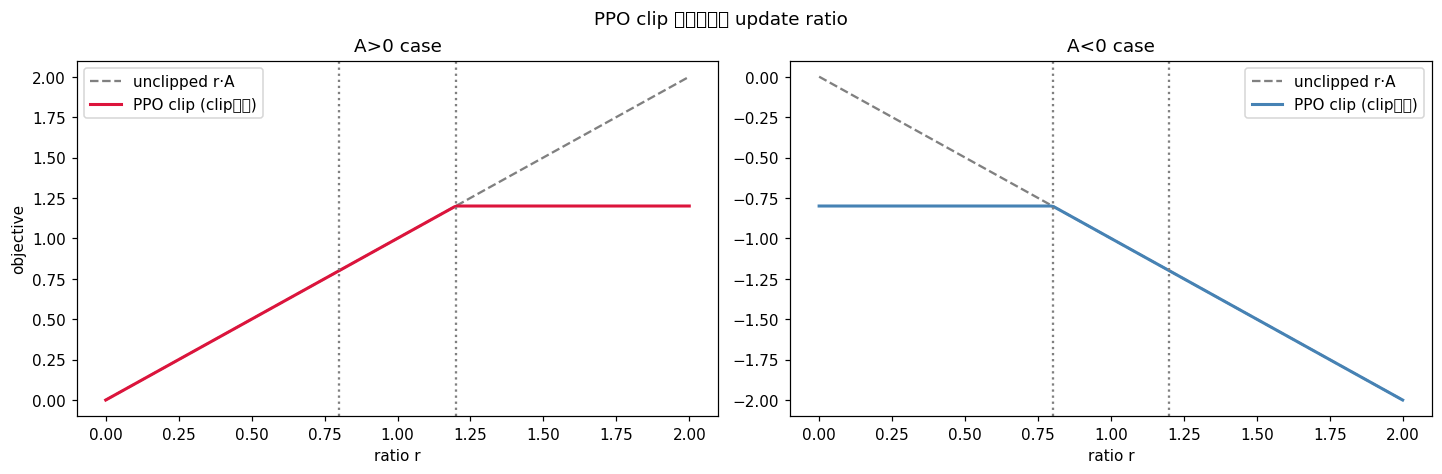

In [4]:
import numpy as np
import matplotlib.pyplot as plt

r = np.linspace(0.0, 2.0, 200)
A_pos = 1.0; A_neg = -1.0
eps = 0.2

# 标准 PPO clip
ratio_clip = np.clip(r, 1-eps, 1+eps)
obj_pos = np.minimum(r * A_pos, ratio_clip * A_pos)
obj_neg = np.minimum(r * A_neg, ratio_clip * A_neg)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), dpi=110, constrained_layout=True)
axes[0].plot(r, r*A_pos, ls="--", color="gray", label="unclipped r·A")
axes[0].plot(r, obj_pos, color="crimson", lw=2, label="PPO clip (clip正部)")
axes[0].axvline(0.8, ls=":", color="gray"); axes[0].axvline(1.2, ls=":", color="gray")
axes[0].set_xlabel("ratio r"); axes[0].set_ylabel("objective"); axes[0].set_title("A>0 case")
axes[0].legend()

axes[1].plot(r, r*A_neg, ls="--", color="gray", label="unclipped r·A")
axes[1].plot(r, obj_neg, color="steelblue", lw=2, label="PPO clip (clip负部)")
axes[1].axvline(0.8, ls=":", color="gray"); axes[1].axvline(1.2, ls=":", color="gray")
axes[1].set_xlabel("ratio r"); axes[1].set_title("A<0 case")
axes[1].legend()
plt.suptitle("PPO clip 控制过大的 update ratio")
plt.show()


## 7. 工程案例: minimal PPO on toy bandit


In [5]:
import numpy as np
import torch
import torch.nn.functional as F
torch.manual_seed(20240717)

N = 4
true_mu = np.array([0.2, 0.6, 0.5, 0.4])
eps = 0.2

# old logits (用于 ratio)
old_logits = torch.zeros(N)
logits = torch.zeros(N, requires_grad=True)
opt = torch.optim.Adam([logits], lr=0.1)

eps_clip = 0.2
history = []
for step in range(2000):
    logits_val = logits.detach()
    # sample action with current policy (compute later ratio)
    probs = F.softmax(logits, dim=0)
    a = torch.multinomial(probs, 1)
    adv = float(true_mu[int(a)]) - 0.4  # advantage vs average (540m/4=0.45)
    # PPO ratio
    old_prob = F.softmax(old_logits, dim=0)[a]
    new_prob = probs[a]
    r_t = (new_prob / old_prob).item()
    # Use surrogate
    surrogate = torch.log(new_prob) * adv
    if adv >= 0:
        r_clipped = min(r_t, 1 + eps_clip)
    else:
        r_clipped = max(r_t, 1 - eps_clip)
    # 实践上用 PyTorch 而 stop-gradient:  在比例 由 detach 模拟
    loss = -surrogate * r_clipped
    opt.zero_grad(); loss.backward(); opt.step()
    old_logits = logits.detach()
    history.append(adv)

import numpy as np
print(f"PPO last-100 advantage = {np.mean(history[-100:]):.4f}")
print(f"final probs = {F.softmax(logits, dim=0).detach().numpy()}")
print(f"true best arm = {np.argmax(true_mu)}")


PPO last-100 advantage = 0.2000
final probs = [6.1410457e-05 9.9974722e-01 1.6294040e-04 2.8498389e-05]
true best arm = 1


## 8. pitfalls
- PPO 必须保留 reference 关键点: clip 是 ratio 上做, 不让 update step 过大
- DPO 不需要 reward model 训练; 但 implicit 加了 BT 假设 (transitivity + scale)
- reference model 在 RLHF 里保险防止 degeneration — 不要把它去掉
- KL 系数 β 太大 → 学不到东西; 太小 → 模型退化到 reward hacking
- pairwise preference 无法表示 ties; Plackett-Luce 对列表更好
- 草稿要避免数据 set 太小 → 训出的 reward model 单一外侧 combo 类, 训数据少偏向就会偷懒
- PPO ratio 极限大: 不能简单 token by token 计算 ratio 的, 应该 per-response 累 product, 取 log 防数值 underflow

## 9. 课后 → exercises.md

## 10. 参考
| 出处 | 章节 |
|---|---|
| Christiano et al. 2017 | RLHF 起源 |
| Schulman et al. 2017 | PPO |
| Rafailov et al. 2023 | DPO |
